In [14]:
# Libraries for data manipulation
import pandas as pd
import numpy as np

# Library for plotting
import matplotlib.pyplot as plt

# Model and tools from scikit-learn
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Load the CSV with 'semana' already parsed as date
df = pd.read_csv('data/raw/influenza_parana_semanal.csv', parse_dates=['semana'])

# Set 'semana' as index (makes date slicing easier)
df = df.set_index('semana')

# Filter the period of interest: 2024-01 to 2025-01
df = df.loc['2024-01-01':'2025-01-31']

# Show series length and first rows
print(f'Total weeks: {len(df)}')
print(df.head())

Total weeks: 54
            casos
semana           
2024-01-01      1
2024-01-08      4
2024-01-15      7
2024-01-22      8
2024-01-29      6


In [15]:
# Lags: values from previous weeks
df['lag_1'] = df['casos'].shift(1)   # value from 1 week ago
df['lag_2'] = df['casos'].shift(2)   # value from 2 weeks ago
df['lag_4'] = df['casos'].shift(4)   # value from 4 weeks ago
df['lag_8'] = df['casos'].shift(8)   # value from 8 weeks ago

# Rolling means: average of last N weeks (shifted by 1 to avoid leakage)
df['ma_4'] = df['casos'].shift(1).rolling(4).mean()
df['ma_8'] = df['casos'].shift(1).rolling(8).mean()

# Calendar features
df['mes'] = df.index.month                                  # 1 to 12
df['semana_ano'] = df.index.isocalendar().week.astype(int)  # 1 to 52

# Drop the first rows that became NaN because of shift/rolling
df = df.dropna()

print(f'Total rows after feature engineering: {len(df)}')
print(df.head())

Total rows after feature engineering: 46
            casos  lag_1  lag_2  lag_4  lag_8   ma_4    ma_8  mes  semana_ano
semana                                                                       
2024-02-26      8   12.0    5.0    6.0    1.0   6.50   5.750    2           9
2024-03-04     20    8.0   12.0    3.0    4.0   7.00   6.625    3          10
2024-03-11     21   20.0    8.0    5.0    7.0  11.25   8.625    3          11
2024-03-18     28   21.0   20.0   12.0    8.0  15.25  10.375    3          12
2024-03-25     25   28.0   21.0    8.0    6.0  19.25  12.875    3          13


In [19]:
# Split into train (80%) and test (20%), keeping chronological order
split = int(len(df) * 0.8)
train = df.iloc[:split]
test = df.iloc[split:]

# Baseline: predict the last train value for every test week
baseline_pred = [train['casos'].iloc[-1]] * len(test)

# Compute the two error metrics
rmse_baseline = np.sqrt(mean_squared_error(test['casos'], baseline_pred))
mape_baseline = mean_absolute_percentage_error(test['casos'], baseline_pred)

print(f'Baseline - RMSE: {rmse_baseline:.2f} | MAPE: {mape_baseline:.2%}')

Baseline - RMSE: 30.01 | MAPE: 650.07%


In [23]:
# List of features that go into the model
features = ['lag_1', 'lag_2', 'lag_4', 'lag_8', 'ma_4', 'ma_8', 'mes', 'semana_ano']

# X = inputs, y = target
X = df[features]
y = df['casos']

# Temporal cross-validation: 3 folds, no shuffling
tscv = TimeSeriesSplit(n_splits=3)

# Lists to store per-fold error
rmse_scores = []
mape_scores = []

# Loop over the 3 folds
for train_idx, test_idx in tscv.split(X):
    # Split train and test for the current fold
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Random Forest: 100 trees, fixed seed
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Predictions on test
    preds = model.predict(X_test)
    
    # Store the fold error
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, preds)))
    mape_scores.append(mean_absolute_percentage_error(y_test, preds))

# Average over the 3 folds
print(f'Default RF - mean RMSE: {np.mean(rmse_scores):.2f} | mean MAPE: {np.mean(mape_scores):.2%}')

Default RF - mean RMSE: 23.67 | mean MAPE: 149.80%


In [28]:
# Hyperparameter grid to test
param_grid = {
    'n_estimators': [50, 100, 200],       # number of trees
    'max_depth': [None, 5, 10],           # maximum depth
    'min_samples_split': [2, 5]           # minimum samples to split a node
}

# Grid search with temporal validation
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=tscv,                              # same temporal validation
    scoring='neg_root_mean_squared_error',# metric (negative by convention)
    n_jobs=-1                             # use all CPU cores
)

# Run the search
grid.fit(X, y)

print(f'Best parameters: {grid.best_params_}')
print(f'Best RMSE: {-grid.best_score_:.2f}')

Best parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Best RMSE: 23.07


Final model - RMSE: 23.24 | MAPE: 436.49%


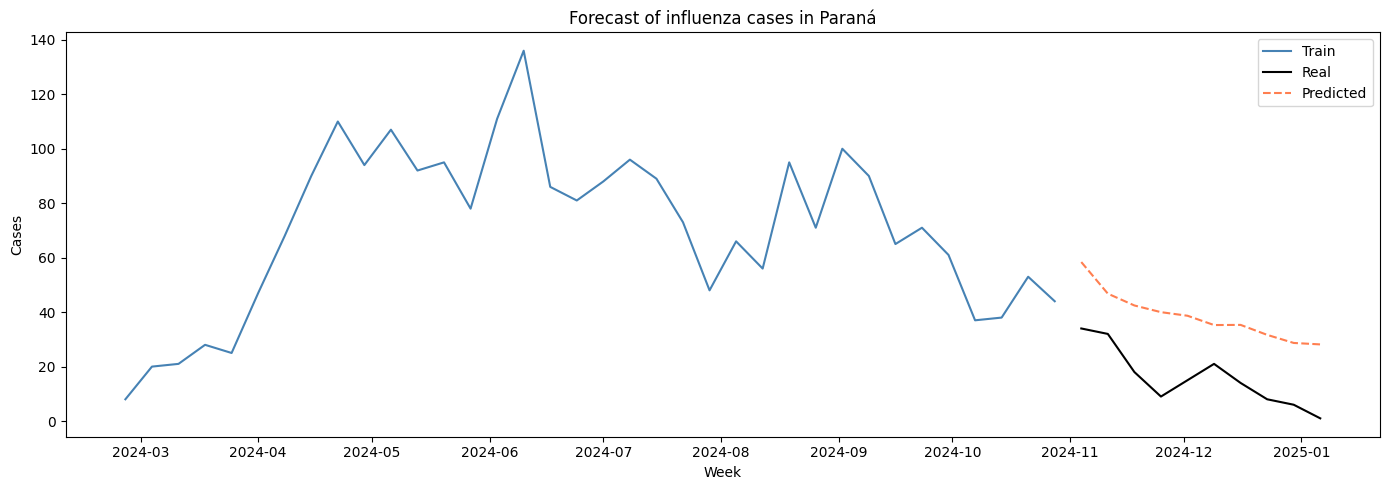

In [32]:
# Final model with the best hyperparameters
best_model = grid.best_estimator_

# Retrain the final model on the full training set (80%)
best_model.fit(train[features], train['casos'])

# Predict on the test set (20%)
preds = best_model.predict(test[features])

# Compute final metrics
rmse = np.sqrt(mean_squared_error(test['casos'], preds))
mape = mean_absolute_percentage_error(test['casos'], preds)

print(f'Final model - RMSE: {rmse:.2f} | MAPE: {mape:.2%}')

# Plot: train, actual and forecast
plt.figure(figsize=(14, 5))
plt.plot(train.index, train['casos'], label='Train', color='steelblue')
plt.plot(test.index, test['casos'], label='Real', color='black')
plt.plot(test.index, preds, label='Predicted', color='coral', linestyle='--')
plt.title('Forecast of influenza cases in Paraná')
plt.xlabel('Week')
plt.ylabel('Cases')
plt.legend()
plt.tight_layout()
plt.savefig('forecast.png', dpi=150)
plt.show()